In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Productos más y menos vendidos

Se revisan las adiciones de 2025 y 2026 para identificar qué productos y categorías sostienen más ventas.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

BASE = '/content/drive/MyDrive/Portfolio/02_Restaurant_Sales/data'

In [3]:
ventas_25 = pd.read_excel(f'{BASE}/VENTAS_2025.xls', sheet_name='Ventas', skiprows=3)
ventas_26 = pd.read_excel(f'{BASE}/VENTAS_ANUAL_2026.xlsx', sheet_name='Ventas', skiprows=3)

ids_validos_25 = ventas_25.loc[(ventas_25['Estado'] == 'Cerrada') & (ventas_25['Total'] > 0), 'Id']
ids_validos_26 = ventas_26.loc[(ventas_26['Estado'] == 'Cerrada') & (ventas_26['Total'] > 0), 'Id']

ad_25 = pd.read_excel(f'{BASE}/VENTAS_2025.xls', sheet_name='Adiciones')
ad_26 = pd.read_excel(f'{BASE}/VENTAS_ANUAL_2026.xlsx', sheet_name='Adiciones')

ad_25 = ad_25[
    (ad_25['Cancelada'] != 'Sí') & (ad_25['Categoría'] != 'Impuestos')
    & (ad_25['Id. Venta'].isin(ids_validos_25))
]
ad_26 = ad_26[
    (ad_26['Cancelada'] != 'Sí') & (ad_26['Categoría'] != 'Impuestos')
    & (ad_26['Id. Venta'].isin(ids_validos_26))
]

ad_25 = ad_25[['Id. Venta', 'Creación', 'Producto', 'Categoría', 'Cantidad', 'Precio']]
ad_26 = ad_26[['Id. Venta', 'Creación', 'Producto', 'Categoría', 'Cantidad', 'Precio']]

ad_25['Año'] = 2025
ad_26['Año'] = 2026

ad = pd.concat([ad_25, ad_26], ignore_index=True)

ad['Creación'] = pd.to_datetime(ad['Creación'])
ad['Mes'] = ad['Creación'].dt.month
ad['Cantidad'] = pd.to_numeric(ad['Cantidad'])
ad['Precio'] = pd.to_numeric(ad['Precio'])
# Precio ya es el importe de la línea (Cantidad x precio unitario), no precio unitario
ad['Ingreso'] = ad['Precio']

ad.head()

,Id. Venta,Creación,Producto,Categoría,Cantidad,Precio,Año,Mes,Ingreso
0,13275,2025-12-31 17:04:23,Charola suprema,charolas,1.0,1200.0,2025,12,1200.0
1,13275,2025-12-31 17:04:23,Charola mediana,charolas,2.0,1600.0,2025,12,1600.0
2,13275,2025-12-31 17:05:17,Charola mediana,charolas,1.0,800.0,2025,12,800.0
3,13275,2025-12-31 17:51:06,Charola mediana,charolas,2.0,1600.0,2025,12,1600.0
4,13275,2025-12-31 18:00:54,Charola suprema,charolas,1.0,1200.0,2025,12,1200.0


## Productos con más movimiento

In [4]:
ventas_prod = ad.groupby('Producto', as_index=False).agg({
    'Cantidad': 'sum',
    'Ingreso': 'sum'
})

top_cantidad = ventas_prod.sort_values('Cantidad', ascending=False).head(15)
top_ingreso = ventas_prod.sort_values('Ingreso', ascending=False).head(15)

display(top_cantidad.round(2))

,Producto,Cantidad,Ingreso
105,Milanesa de pollo Rellena,2880.50,275290.00
20,Charola parrillada,2830.70,283070.00
159,Vaso de agua del dia jamaica,1983.90,41572.92
38,Coca Cola,1895.00,66325.00
72,Hamburguesa Hawaiana,1870.50,168717.50
98,Jarra limonada Fresa 1 litro,1754.62,105277.20
130,Parrillada,1625.50,162667.50
108,Milanesa pollo normal,1201.50,98155.00
6,Arrachera Marinada,954.00,159680.00
96,Jarra de Agua del dia jamaica,846.48,48418.99


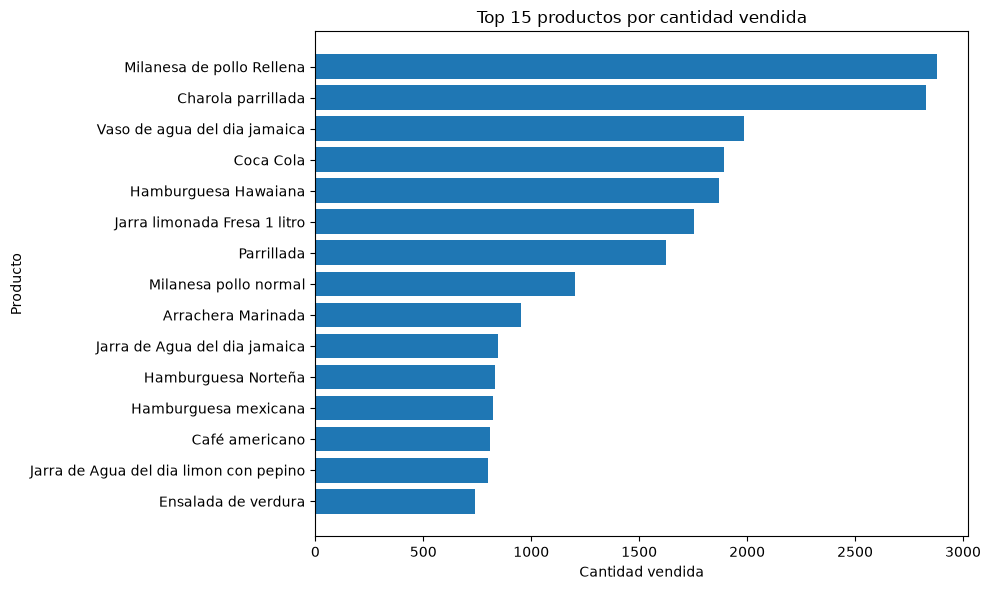

In [5]:
graf = top_cantidad.sort_values('Cantidad')

plt.figure(figsize=(10, 6))
plt.barh(graf['Producto'], graf['Cantidad'])
plt.title('Top 15 productos por cantidad vendida')
plt.xlabel('Cantidad vendida')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

In [6]:
display(top_ingreso.round(2))

,Producto,Cantidad,Ingreso
21,Charola suprema,258.50,310200.0
20,Charola parrillada,2830.70,283070.0
105,Milanesa de pollo Rellena,2880.50,275290.0
72,Hamburguesa Hawaiana,1870.50,168717.5
130,Parrillada,1625.50,162667.5
6,Arrachera Marinada,954.00,159680.0
98,Jarra limonada Fresa 1 litro,1754.62,105277.2
108,Milanesa pollo normal,1201.50,98155.0
40,Coctel de camaron Tropical,550.00,81860.0
19,Charola mediana,101.50,80200.0


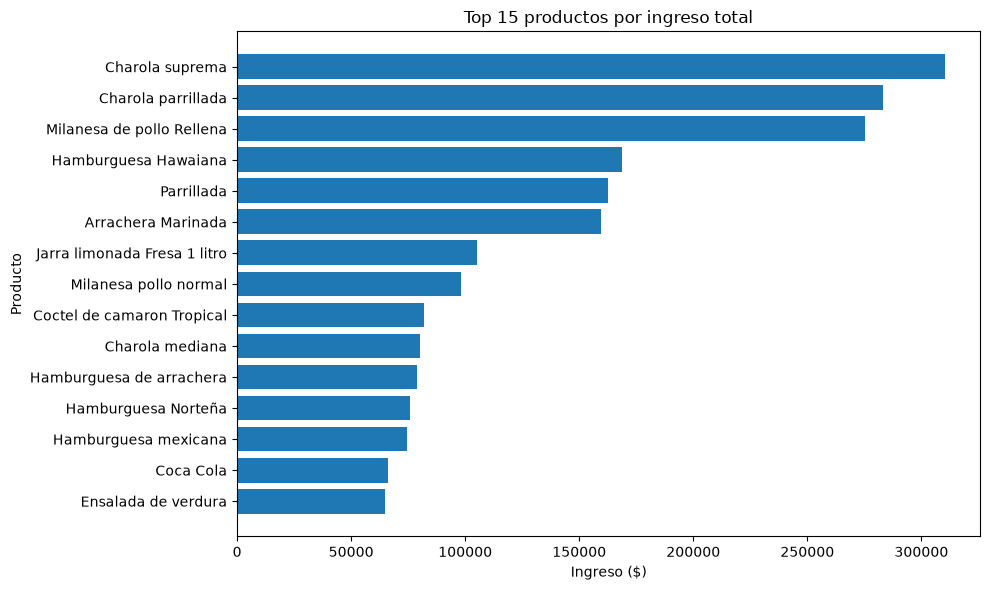

In [7]:
graf = top_ingreso.sort_values('Ingreso')

plt.figure(figsize=(10, 6))
plt.barh(graf['Producto'], graf['Ingreso'])
plt.title('Top 15 productos por ingreso total')
plt.xlabel('Ingreso ($)')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

In [8]:
solo_cantidad = top_cantidad[~top_cantidad['Producto'].isin(top_ingreso['Producto'])]
solo_ingreso = top_ingreso[~top_ingreso['Producto'].isin(top_cantidad['Producto'])]

print('Productos que aparecen solo en el top por cantidad:')
print(', '.join(solo_cantidad['Producto']))

print('\nProductos que aparecen solo en el top por ingreso:')
print(', '.join(solo_ingreso['Producto']))

Productos que aparecen solo en el top por cantidad:
Vaso de agua del dia jamaica, Jarra de Agua del dia jamaica, Café americano, Jarra de Agua del dia limon con pepino

Productos que aparecen solo en el top por ingreso:
Charola suprema, Coctel de camaron Tropical, Charola mediana, Hamburguesa de arrachera


Los productos que salen en ambos rankings combinan volumen e ingreso. Los que solo aparecen por cantidad pueden tener un precio bajo, mientras que los que solo aparecen por ingreso pueden vender menos unidades pero aportar más dinero.

## Productos con poco movimiento

In [9]:
bajo = ventas_prod[ventas_prod['Cantidad'] > 0].sort_values(
    ['Cantidad', 'Ingreso']
).head(15)

display(bajo.round(2))

,Producto,Cantidad,Ingreso
156,Te de frutos rojos,1.0,25.0
77,Helado Flotante napolitano,1.0,35.0
48,"Crepa Queso, jamón y piña",1.0,45.0
0,Affogato,1.0,55.0
103,Margarita,1.0,60.0
49,Crepa queso crema con durazno,1.0,75.0
50,Crepa queso crema y mermelada,1.0,75.0
41,Comida del día,1.0,85.0
135,Pizza mexicana,1.0,170.0
63,Filete Mignon,1.0,280.0


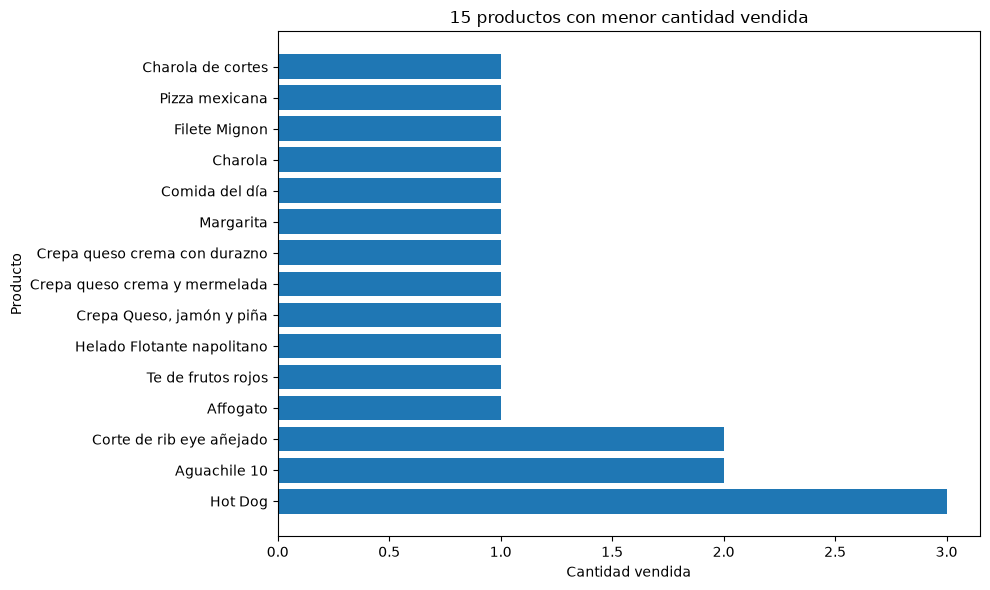

In [10]:
graf = bajo.sort_values('Cantidad', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(graf['Producto'], graf['Cantidad'])
plt.title('15 productos con menor cantidad vendida')
plt.xlabel('Cantidad vendida')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

## Categorías que dominan el menú

In [11]:
ventas_cat = ad.groupby('Categoría', as_index=False).agg({
    'Cantidad': 'sum',
    'Ingreso': 'sum'
}).sort_values('Ingreso', ascending=False)

display(ventas_cat.round(2))

,Categoría,Cantidad,Ingreso
41,charolas,3192.70,675370.00
27,Milanesas Y Pollo,4904.00,448045.00
23,Hamburguesas,4651.00,446970.00
11,Cortes,1678.17,275121.10
7,Chilaquiles,2552.50,264755.00
2,Agua Sabor,5963.49,259766.10
32,Pescados Y Mariscos,1556.00,197095.00
31,Parrillada,1667.41,176862.05
25,Huevos Al Gusto,1729.50,169725.00
16,Entradas Y Snacks,1688.50,122012.50


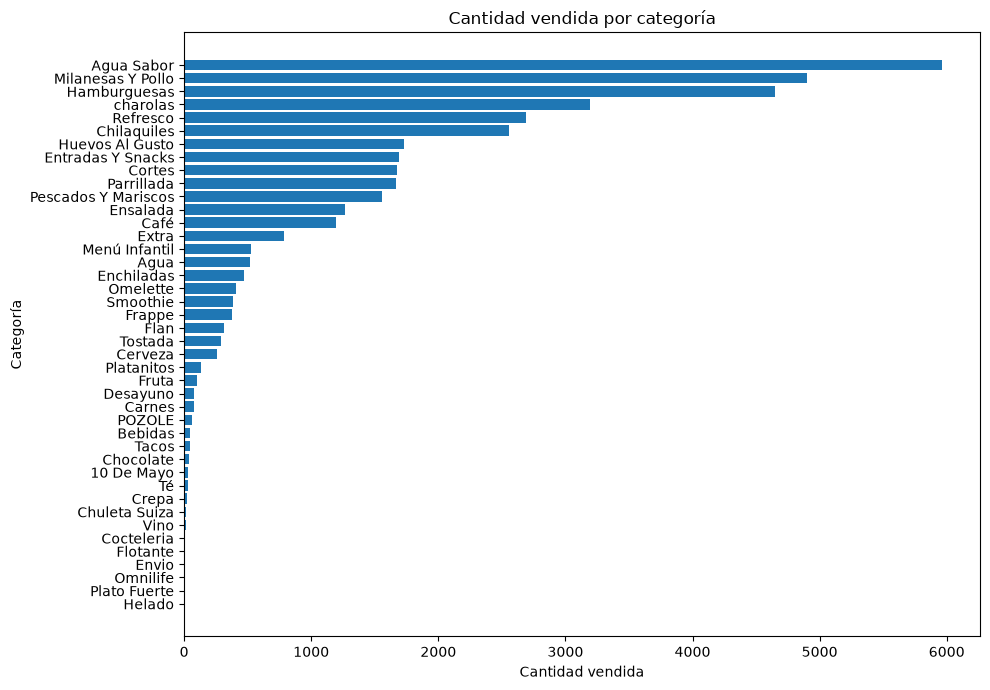

In [12]:
graf = ventas_cat.sort_values('Cantidad')

plt.figure(figsize=(10, 7))
plt.barh(graf['Categoría'], graf['Cantidad'])
plt.title('Cantidad vendida por categoría')
plt.xlabel('Cantidad vendida')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

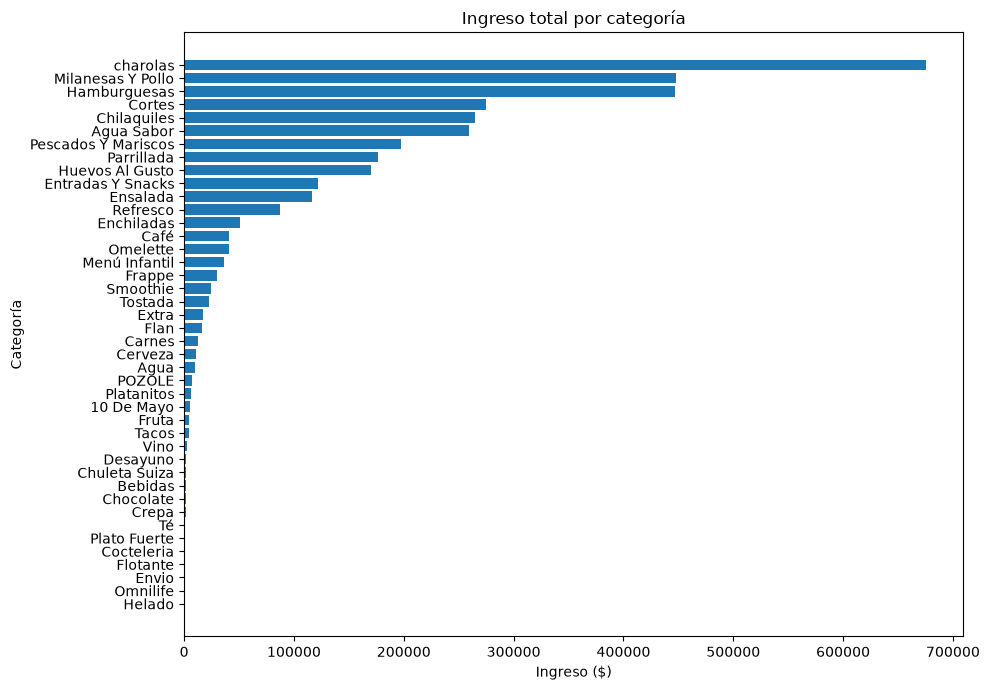

In [13]:
graf = ventas_cat.sort_values('Ingreso')

plt.figure(figsize=(10, 7))
plt.barh(graf['Categoría'], graf['Ingreso'])
plt.title('Ingreso total por categoría')
plt.xlabel('Ingreso ($)')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

## Comparación entre 2025 y 2026

Como 2026 todavía no tiene los mismos meses que 2025, se comparan promedios mensuales. Así se puede ver mejor si cambió la mezcla de productos después de la mudanza y el ajuste de precios.

In [14]:
ultimo_mes = ad.loc[ad['Año'] == 2026, 'Mes'].max() - 1
ad_comp = ad[ad['Mes'] <= ultimo_mes].copy()

meses = ad_comp.groupby('Año')['Mes'].nunique()

cat_anio = ad_comp.groupby(['Año', 'Categoría'], as_index=False).agg({
    'Cantidad': 'sum',
    'Ingreso': 'sum'
})

cat_25 = cat_anio[cat_anio['Año'] == 2025].set_index('Categoría')[['Cantidad', 'Ingreso']]
cat_25 = cat_25.rename(columns={'Cantidad': 'Cantidad_25', 'Ingreso': 'Ingreso_25'})

cat_26 = cat_anio[cat_anio['Año'] == 2026].set_index('Categoría')[['Cantidad', 'Ingreso']]
cat_26 = cat_26.rename(columns={'Cantidad': 'Cantidad_26', 'Ingreso': 'Ingreso_26'})

comp_cat = cat_25.join(cat_26, how='outer').fillna(0).reset_index()

comp_cat['Cantidad_mes_25'] = comp_cat['Cantidad_25'] / meses.loc[2025]
comp_cat['Cantidad_mes_26'] = comp_cat['Cantidad_26'] / meses.loc[2026]
comp_cat['Ingreso_mes_25'] = comp_cat['Ingreso_25'] / meses.loc[2025]
comp_cat['Ingreso_mes_26'] = comp_cat['Ingreso_26'] / meses.loc[2026]

comp_cat['Cambio_cantidad_%'] = (
    (comp_cat['Cantidad_mes_26'] / comp_cat['Cantidad_mes_25']) - 1
) * 100

comp_cat.loc[comp_cat['Cantidad_mes_25'] == 0, 'Cambio_cantidad_%'] = pd.NA

comp_cat['Part_25'] = (comp_cat['Cantidad_25'] / comp_cat['Cantidad_25'].sum()) * 100
comp_cat['Part_26'] = (comp_cat['Cantidad_26'] / comp_cat['Cantidad_26'].sum()) * 100
comp_cat['Cambio_part_pp'] = comp_cat['Part_26'] - comp_cat['Part_25']

comp_cat['Precio_prom_25'] = comp_cat['Ingreso_25'] / comp_cat['Cantidad_25']
comp_cat['Precio_prom_26'] = comp_cat['Ingreso_26'] / comp_cat['Cantidad_26']

tabla_cat = comp_cat[[
    'Categoría', 'Cantidad_mes_25', 'Cantidad_mes_26',
    'Ingreso_mes_25', 'Ingreso_mes_26',
    'Cambio_cantidad_%', 'Cambio_part_pp',
    'Precio_prom_25', 'Precio_prom_26'
]]

display(tabla_cat.sort_values('Cambio_part_pp', ascending=False).round(1))

,Categoría,Cantidad_mes_25,Cantidad_mes_26,Ingreso_mes_25,Ingreso_mes_26,Cambio_cantidad_%,Cambio_part_pp,Precio_prom_25,Precio_prom_26
4,Café,34.1,76.4,937.2,2874.4,124.1,2.6,27.5,37.6
27,Milanesas Y Pollo,234.4,233.1,20083.3,22913.9,-0.6,1.6,85.7,98.3
7,Chilaquiles,118.1,130.9,11336.1,14725.0,10.9,1.6,96.0,112.5
15,Ensalada,50.3,70.9,4231.1,6996.7,40.8,1.5,84.1,98.7
11,Cortes,66.5,82.8,10886.8,14278.9,24.5,1.4,163.7,172.4
25,Huevos Al Gusto,79.1,91.7,7192.2,9684.4,16.0,1.3,91.0,105.6
16,Entradas Y Snacks,71.8,83.1,4780.3,6626.7,15.7,1.1,66.5,79.7
1,Agua,19.1,30.7,345.6,649.4,60.8,0.8,18.1,21.1
14,Enchiladas,16.3,26.5,1651.4,3095.8,62.2,0.7,101.1,116.8
28,Omelette,14.8,24.9,1355.6,2650.0,68.4,0.7,91.7,106.5


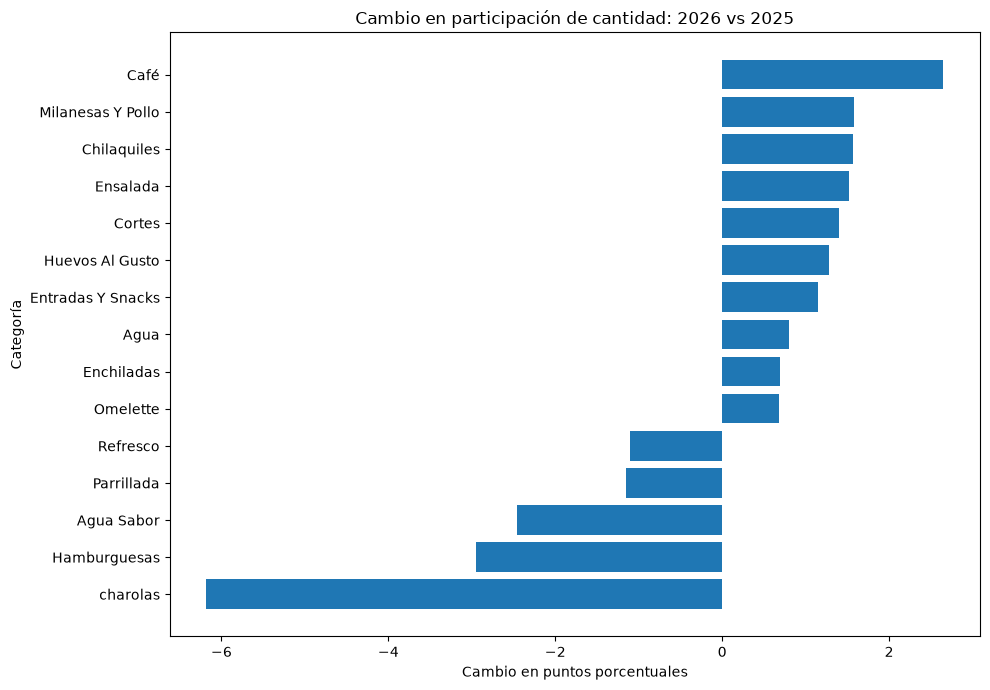

In [15]:
graf = comp_cat.reindex(comp_cat['Cambio_part_pp'].abs().sort_values(ascending=False).index).head(15)
graf = graf.sort_values('Cambio_part_pp')

plt.figure(figsize=(10, 7))
plt.barh(graf['Categoría'], graf['Cambio_part_pp'])
plt.title('Cambio en participación de cantidad: 2026 vs 2025')
plt.xlabel('Cambio en puntos porcentuales')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

In [16]:
prod_anio = ad_comp.groupby(['Año', 'Producto'], as_index=False).agg({
    'Cantidad': 'sum',
    'Ingreso': 'sum'
})

prod_25 = prod_anio[prod_anio['Año'] == 2025].set_index('Producto')[['Cantidad', 'Ingreso']]
prod_25 = prod_25.rename(columns={'Cantidad': 'Cantidad_25', 'Ingreso': 'Ingreso_25'})

prod_26 = prod_anio[prod_anio['Año'] == 2026].set_index('Producto')[['Cantidad', 'Ingreso']]
prod_26 = prod_26.rename(columns={'Cantidad': 'Cantidad_26', 'Ingreso': 'Ingreso_26'})

comp_prod = prod_25.join(prod_26, how='outer').fillna(0).reset_index()

comp_prod['Cantidad_mes_25'] = comp_prod['Cantidad_25'] / meses.loc[2025]
comp_prod['Cantidad_mes_26'] = comp_prod['Cantidad_26'] / meses.loc[2026]
comp_prod['Dif_mes'] = comp_prod['Cantidad_mes_26'] - comp_prod['Cantidad_mes_25']

comp_prod['Cambio_%'] = (
    (comp_prod['Cantidad_mes_26'] / comp_prod['Cantidad_mes_25']) - 1
) * 100

comp_prod.loc[comp_prod['Cantidad_mes_25'] == 0, 'Cambio_%'] = pd.NA

cambios_prod = comp_prod[
    (comp_prod['Cantidad_25'] + comp_prod['Cantidad_26']) >= 20
]

suben = cambios_prod[cambios_prod['Dif_mes'] > 0].sort_values('Dif_mes', ascending=False).head(10)
bajan = cambios_prod[cambios_prod['Dif_mes'] < 0].sort_values('Dif_mes').head(10)

### Productos que más subieron por promedio mensual

In [17]:
display(suben[[
    'Producto', 'Cantidad_mes_25', 'Cantidad_mes_26',
    'Dif_mes', 'Cambio_%'
]].round(1))

,Producto,Cantidad_mes_25,Cantidad_mes_26,Dif_mes,Cambio_%
98,Jarra limonada Fresa 1 litro,71.5,108.3,36.8,51.5
9,Café americano,25.7,50.2,24.6,95.7
59,Ensalada de verdura,27.4,44.7,17.2,62.8
108,Milanesa pollo normal,49.7,65.6,15.9,32.1
6,Arrachera Marinada,36.1,50.8,14.7,40.6
163,manzanita,7.9,18.0,10.1,128.2
1,Agua Embotellada,13.8,23.4,9.6,69.8
56,Enchiladas suizas Paquete,6.9,16.1,9.2,132.0
23,Chilaquiles Asada en Paquete,14.1,23.0,8.9,63.6
11,Capuchino,5.6,14.1,8.6,154.0


### Productos que más bajaron por promedio mensual

In [18]:
display(bajan[[
    'Producto', 'Cantidad_mes_25', 'Cantidad_mes_26',
    'Dif_mes', 'Cambio_%'
]].round(1))

,Producto,Cantidad_mes_25,Cantidad_mes_26,Dif_mes,Cambio_%
20,Charola parrillada,182.7,57.2,-125.6,-68.7
97,Jarra de Agua del dia limon con pepino,77.0,4.9,-72.1,-93.7
72,Hamburguesa Hawaiana,113.3,63.9,-49.4,-43.6
38,Coca Cola,108.3,72.4,-35.9,-33.1
130,Parrillada,94.0,62.7,-31.3,-33.3
160,Vaso de agua del dia limon con pepino,28.1,6.1,-22.1,-78.4
75,Hamburguesa mexicana,48.1,31.0,-17.1,-35.6
159,Vaso de agua del dia jamaica,96.3,82.2,-14.1,-14.6
105,Milanesa de pollo Rellena,142.4,129.2,-13.3,-9.3
129,Paquete extra,14.3,1.4,-12.9,-89.9


In [19]:
protege = ', '.join(top_ingreso['Producto'].head(3))
baja_venta = ', '.join(bajo['Producto'].head(3))
suben_26 = ', '.join(suben['Producto'].head(3))
bajan_26 = ', '.join(bajan['Producto'].head(3))

print(f'Productos a proteger por ingreso: {protege}.')
print(f'Productos con poca salida para revisar: {baja_venta}.')
print(f'Productos con mayor avance mensual en 2026: {suben_26}.')
print(f'Productos con mayor baja mensual en 2026: {bajan_26}.')

Productos a proteger por ingreso: Charola suprema, Charola parrillada, Milanesa de pollo Rellena.
Productos con poca salida para revisar: Te de frutos rojos, Helado Flotante napolitano, Crepa Queso, jamón y piña.
Productos con mayor avance mensual en 2026: Jarra limonada Fresa 1 litro, Café americano, Ensalada de verdura.
Productos con mayor baja mensual en 2026: Charola parrillada, Jarra de Agua del dia limon con pepino, Hamburguesa Hawaiana.


## Cierre

Conviene proteger y destacar los productos que aparecen arriba tanto por cantidad como por ingreso, porque son los que más sostienen el menú. La cola de baja venta se puede revisar para simplificar compras, preparación o espacio en carta. Los cambios de 2026 deben leerse considerando la pérdida del mercado cercano, la mudanza frente al parque y el aumento de precios, ya que los tres factores pueden haber cambiado la mezcla de consumo.